#### Comparison of Average-case capacity for all protocols: GRR, SS, OUE, SUE, BLH, OLH and THE.

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Capacities methods for all protocols

def capacity_grr(epsilon, k):
    return (k * np.exp(epsilon)) / (np.exp(epsilon) + k -1)

def capacity_ss(epsilon, k, omega):
    return np.exp(epsilon) * k / ((omega*np.exp(epsilon) + k - omega))

def capacity_lh(epsilon, k, g):
    log_alpha = epsilon + math.log(g) - math.log(k) - math.log(np.exp(epsilon) + g - 1)
    log_beta_first = k * math.log(g-1) - math.log(k) - (k-1)*math.log(g)
    beta = np.exp(log_beta_first) * (1-np.exp(epsilon))/(np.exp(epsilon) + g - 1)
    return (np.exp(log_alpha) + beta) * k

def capacity_sue(epsilon, k):
    p = np.exp(epsilon/2)/(np.exp(epsilon/2) + 1)
    return (p + p**(k-1) * (1-2*p)) / (1-p)
    
def capacity_oue(epsilon, k):
    q = 1 / (np.exp(epsilon) + 1)
    return ( (1-q)**(k-1) * (2*q - 1) + 1 ) / (2*q)

def capacity_the(epsilon, k, theta):
    p = 1 - np.exp((epsilon * (theta-1))/2) / 2
    q = (np.exp(- (epsilon * theta)/2)) / 2

    return (1-q)**(k-1) * (1-p/q) + p/q

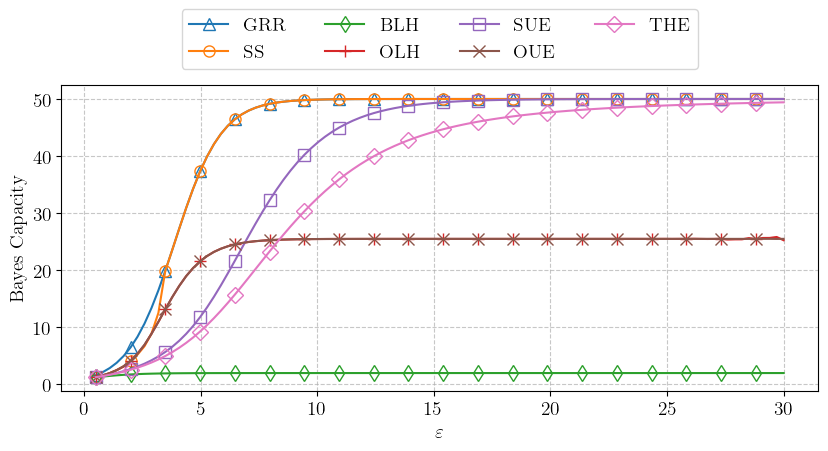

In [ ]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "figure.figsize":(8.5,4.75),
    "font.size":14
})

# Parameters
k = 50 # Domain size
epsilons = np.linspace(0.5,30,100) # Epsilon values (x axis)

markers = ["^", "o", "s", "x", "D", "d", "+"]
cmap = plt.get_cmap("tab10")

Y = [capacity_grr(eps, k) for eps in epsilons]
plt.plot(epsilons, Y, label="GRR", markersize=8, marker=markers[0], markevery=5, markerfacecolor='none', markeredgecolor=cmap(0), color=cmap(0))

Y = [capacity_ss(eps, k, omega=max(1,round(k / (np.exp(eps)+1)))) for eps in epsilons]
plt.plot(epsilons, Y, label="SS", markersize=8, marker=markers[1], markevery=5, markerfacecolor='none', markeredgecolor=cmap(1), color=cmap(1))

Y = [capacity_lh(eps, k, g=2) for eps in epsilons]
plt.plot(epsilons, Y, label="BLH", markersize=8, marker=markers[5], markevery=5, markerfacecolor='none', markeredgecolor=cmap(2), color=cmap(2))

Y = [capacity_lh(eps, k, g=round(np.exp(eps)+1)) for eps in epsilons]
plt.plot(epsilons, Y, label="OLH", markersize=8, marker=markers[6], markevery=5, markerfacecolor='none', markeredgecolor=cmap(3), color=cmap(3))

Y = [capacity_sue(eps, k) for eps in epsilons]
plt.plot(epsilons, Y, label="SUE", markersize=8, marker=markers[2], markevery=5, markerfacecolor='none', markeredgecolor=cmap(4), color=cmap(4))

Y = [capacity_oue(eps, k) for eps in epsilons]
plt.plot(epsilons, Y, label="OUE", markersize=8, marker=markers[3], markevery=5, markerfacecolor='none', markeredgecolor=cmap(5), color=cmap(5))

Y = [capacity_the(eps, k, theta=0.75) for eps in epsilons]
plt.plot(epsilons, Y, label="THE", markersize=8, marker=markers[4], markevery=5, markerfacecolor='none', markeredgecolor=cmap(6), color=cmap(6))

plt.xlabel("$\\varepsilon$")
plt.ylabel("Bayes Capacity")
plt.grid(alpha=.7, linestyle="--")
plt.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
)
plt.tight_layout()
plt.show()